In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/preprocessed_data.csv', parse_dates=['datetime'])

print(f"Data loaded: {len(df)} rows, {len(df.columns)} columns")
print(f"Anomaly column check: {df['anomaly'].value_counts().to_dict()}")

Data loaded: 44534 rows, 29 columns
Anomaly column check: {0.0: 32262, 1.0: 12272}


In [2]:
sensor_cols = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
               'Pressure', 'Temperature', 'Thermocouple',
               'Voltage', 'Volume Flow RateRMS']

def zscore_detect(df, sensor_cols, threshold=3.0):
    
    zscore_df = pd.DataFrame(index=df.index)
    
    for sensor in sensor_cols:
        mean_col = f'{sensor}_rolling_mean'
        std_col = f'{sensor}_rolling_std'
        
        zscore_df[f'{sensor}_zscore'] = (
            (df[sensor] - df[mean_col]) / df[std_col]
        )
    
    zscore_df['max_zscore'] = zscore_df.abs().max(axis=1)
    
    predictions = (zscore_df['max_zscore'] > threshold).astype(int)
    
    return predictions, zscore_df

predictions_zscore, zscore_details = zscore_detect(df, sensor_cols, threshold=3.0)

print(f"Total anomalies detected: {predictions_zscore.sum()}")
print(f"Total actual anomalies: {int(df['anomaly'].sum())}")
print(f"Detection rate: {round(predictions_zscore.sum() / df['anomaly'].sum() * 100, 2)}%")

Total anomalies detected: 1676
Total actual anomalies: 12272
Detection rate: 13.66%


In [3]:
y_true = df['anomaly'].astype(int)
y_pred = predictions_zscore.astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print("=" * 40)
print("Z-SCORE MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"Threshold used: 3.0 sigma")
print(f"Window size: 50")
print()
print(f"Precision:  {round(precision, 4)}")
print(f"Recall:     {round(recall, 4)}")
print(f"F1 Score:   {round(f1, 4)}")
print()
print("Confusion Matrix:")
print(f"  True Negatives:  {cm[0][0]}")
print(f"  False Positives: {cm[0][1]}")
print(f"  False Negatives: {cm[1][0]}")
print(f"  True Positives:  {cm[1][1]}")

Z-SCORE MODEL EVALUATION RESULTS
Threshold used: 3.0 sigma
Window size: 50

Precision:  0.3365
Recall:     0.046
F1 Score:   0.0809

Confusion Matrix:
  True Negatives:  31150
  False Positives: 1112
  False Negatives: 11708
  True Positives:  564


In [4]:
thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

results = []

for t in thresholds:
    preds, _ = zscore_detect(df, sensor_cols, threshold=t)
    p = precision_score(y_true, preds.astype(int), zero_division=0)
    r = recall_score(y_true, preds.astype(int), zero_division=0)
    f = f1_score(y_true, preds.astype(int), zero_division=0)
    detected = preds.sum()
    results.append({
        'threshold': t,
        'precision': round(p, 4),
        'recall': round(r, 4),
        'f1': round(f, 4),
        'detected': detected
    })

results_df = pd.DataFrame(results)
print("Threshold experiment results:")
print(results_df.to_string(index=False))

best_row = results_df.loc[results_df['f1'].idxmax()]
print(f"\nBest threshold by F1 score: {best_row['threshold']}")
print(f"Best F1: {best_row['f1']}")
print(f"Precision at best: {best_row['precision']}")
print(f"Recall at best: {best_row['recall']}")

Threshold experiment results:
 threshold  precision  recall     f1  detected
       0.5     0.2756  0.9998 0.4321     44520
       1.0     0.2764  0.9854 0.4317     43754
       1.5     0.2766  0.7984 0.4109     35419
       2.0     0.2833  0.4355 0.3433     18870
       2.5     0.3031  0.1582 0.2079      6404
       3.0     0.3365  0.0460 0.0809      1676
       3.5     0.4352  0.0167 0.0322       471
       4.0     0.5444  0.0080 0.0157       180

Best threshold by F1 score: 0.5
Best F1: 0.4321
Precision at best: 0.2756
Recall at best: 0.9998


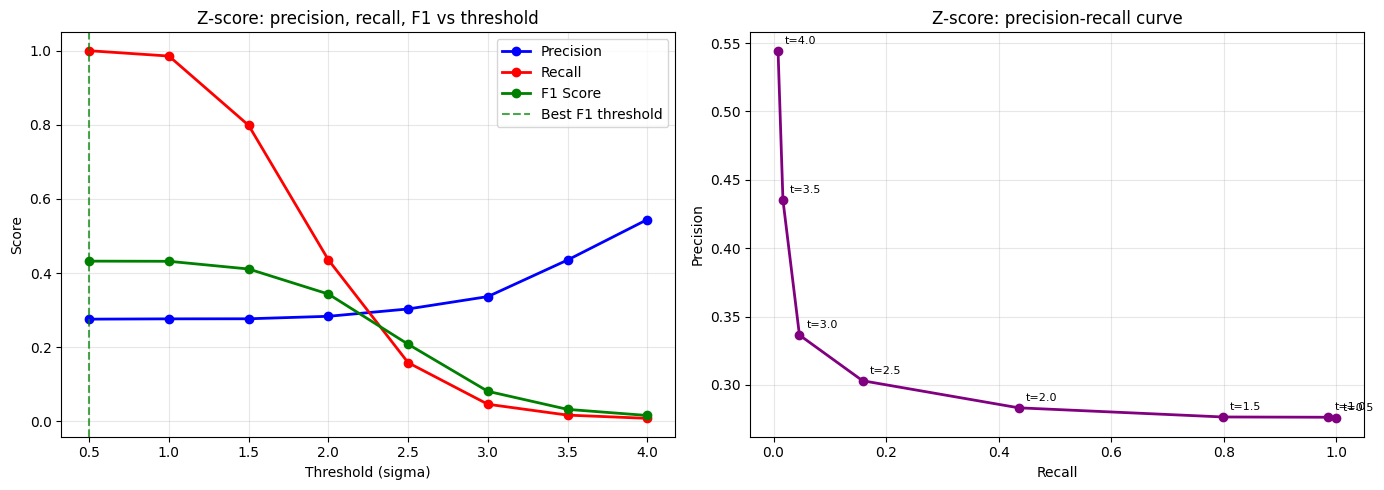

Chart saved to report folder


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['threshold'], results_df['precision'], 
             'b-o', label='Precision', linewidth=2, markersize=6)
axes[0].plot(results_df['threshold'], results_df['recall'], 
             'r-o', label='Recall', linewidth=2, markersize=6)
axes[0].plot(results_df['threshold'], results_df['f1'], 
             'g-o', label='F1 Score', linewidth=2, markersize=6)
axes[0].axvline(x=0.5, color='green', linestyle='--', 
                alpha=0.7, label='Best F1 threshold')
axes[0].set_xlabel('Threshold (sigma)')
axes[0].set_ylabel('Score')
axes[0].set_title('Z-score: precision, recall, F1 vs threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['recall'], results_df['precision'], 
             'purple', linewidth=2, marker='o', markersize=6)
for _, row in results_df.iterrows():
    axes[1].annotate(f"t={row['threshold']}", 
                    (row['recall'], row['precision']),
                    textcoords="offset points",
                    xytext=(5, 5), fontsize=8)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Z-score: precision-recall curve')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../report/zscore_threshold_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to report folder")

## Z-score threshold experiment results

Testing thresholds from 0.5 to 4.0 sigma reveals a clear 
precision-recall tradeoff.

Best F1 score of 0.4321 achieved at threshold = 0.5 sigma
with precision = 0.2756 and recall = 0.9998.

Key observations:
1. At threshold 3.0 (classical statistical rule) recall drops 
   to 0.046 — the model misses 95% of anomalies. This is because 
   many SKAB anomalies are gradual drifts that never produce 
   3-sigma spikes.

2. F1 score is stable between threshold 0.5 and 1.5 — suggesting 
   this range is optimal for this dataset.

3. Precision never exceeds 0.54 regardless of threshold — 
   indicating Z-score generates inherent false alarms due to 
   normal sensor noise crossing the threshold.

This analysis motivates ARIMA as a complementary method — 
capable of detecting gradual drift anomalies that Z-score misses.

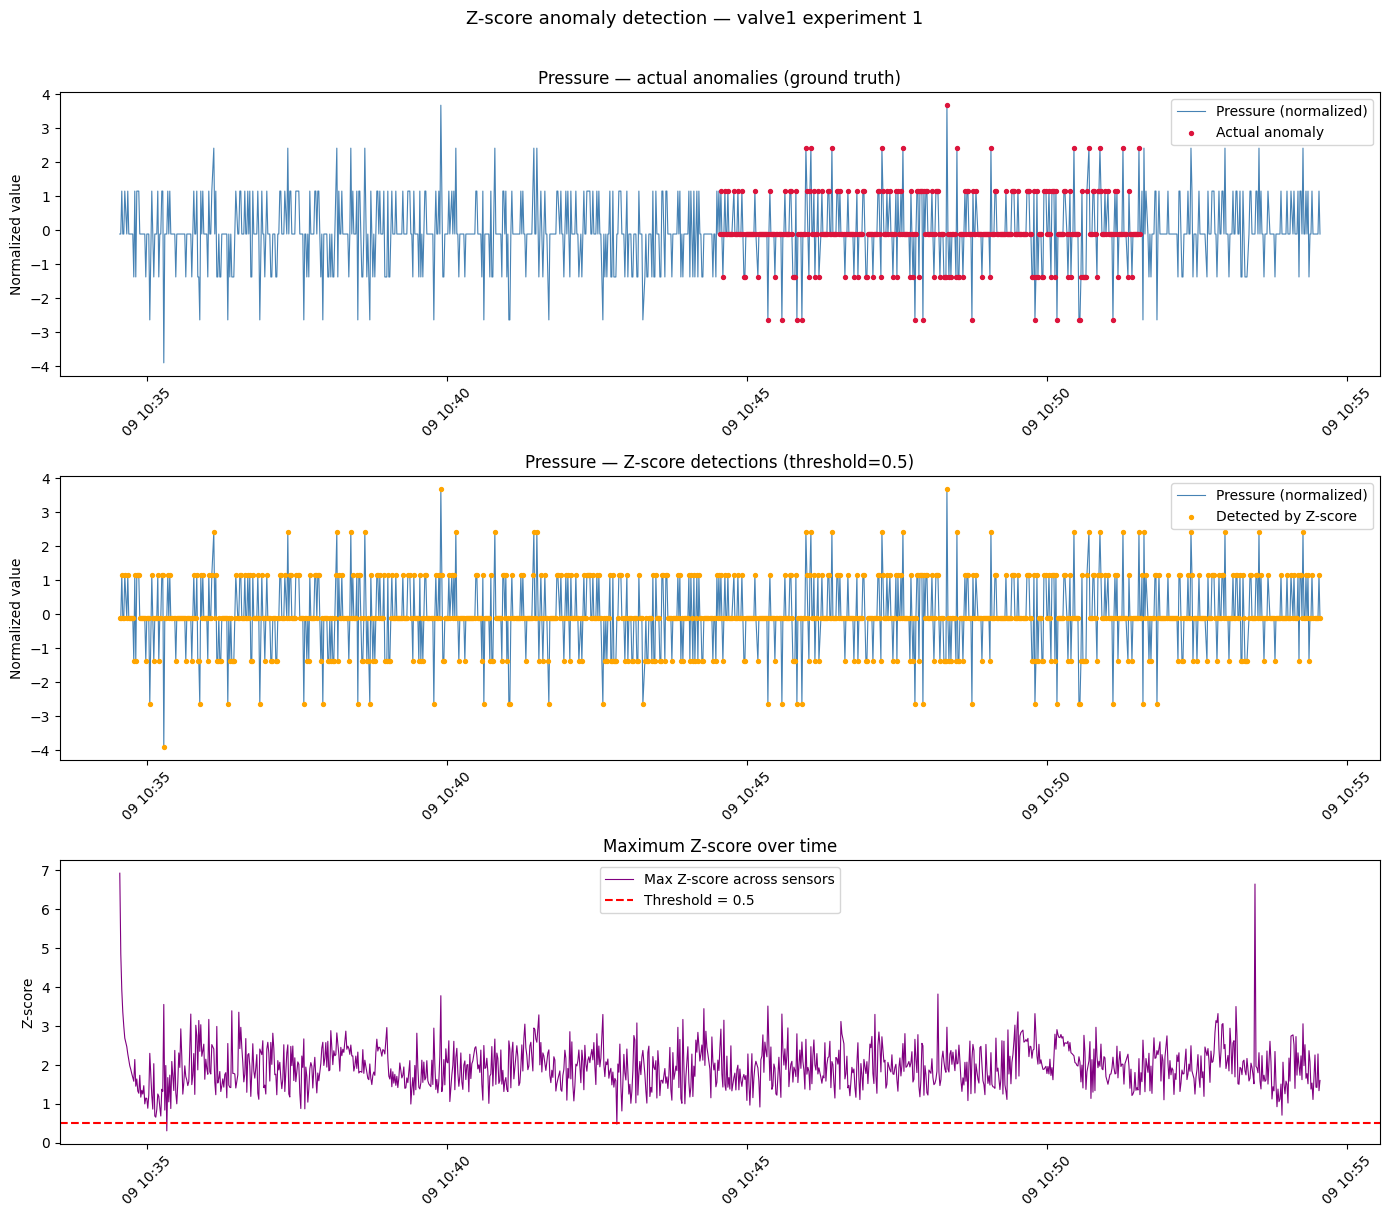

Chart saved to report folder


In [6]:
best_threshold = 0.5
best_predictions, best_zscore_details = zscore_detect(df, sensor_cols, threshold=best_threshold)

sample_mask = (df['filename'] == '1.csv') & (df['anomaly_source'] == 'valve1')
sample = df[sample_mask].copy()
sample_preds = best_predictions[sample_mask]
sample_zscores = best_zscore_details[sample_mask]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(sample['datetime'], sample['Pressure'],
             color='steelblue', linewidth=0.8, label='Pressure (normalized)')
actual_anomalies = sample[sample['anomaly'] == 1.0]
axes[0].scatter(actual_anomalies['datetime'], actual_anomalies['Pressure'],
                color='crimson', s=8, zorder=5, label='Actual anomaly')
axes[0].set_title('Pressure — actual anomalies (ground truth)')
axes[0].set_ylabel('Normalized value')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(sample['datetime'], sample['Pressure'],
             color='steelblue', linewidth=0.8, label='Pressure (normalized)')
detected = sample[sample_preds == 1]
axes[1].scatter(detected['datetime'], detected['Pressure'],
                color='orange', s=8, zorder=5, label='Detected by Z-score')
axes[1].set_title(f'Pressure — Z-score detections (threshold={best_threshold})')
axes[1].set_ylabel('Normalized value')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(sample['datetime'], sample_zscores['max_zscore'],
             color='purple', linewidth=0.8, label='Max Z-score across sensors')
axes[2].axhline(y=best_threshold, color='red', linestyle='--',
                linewidth=1.5, label=f'Threshold = {best_threshold}')
axes[2].set_title('Maximum Z-score over time')
axes[2].set_ylabel('Z-score')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Z-score anomaly detection — valve1 experiment 1', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../report/zscore_detections.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to report folder")